In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [20, 10]

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn import tree

In [2]:
std = 1 # sigma

N = int(1e5)
X = np.random.uniform(size=(N,1))
y =  10 + 10*(X[:,0] > 0.7) - 25*(X[:,0] < 0.2) + 3*(X[:,0] < 0.5)
#y = np.sin(2*np.pi*X[:,0])

eps = np.random.normal(0, std, size=N)
y = y + eps

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

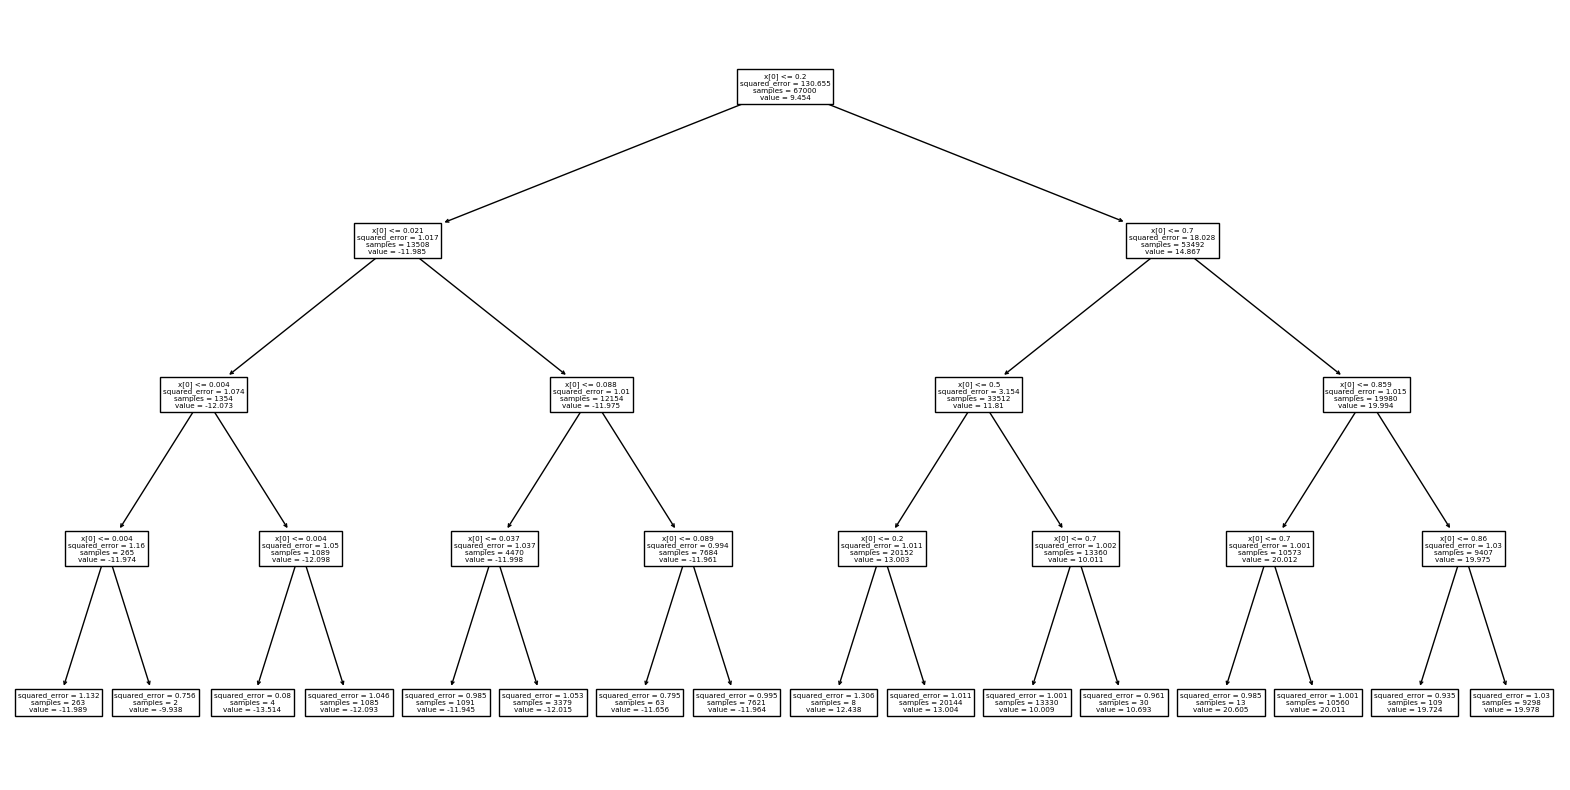

In [4]:
rt = tree.DecisionTreeRegressor(random_state=0, max_depth=4)
rt.fit(X_train,y_train)
_ = tree.plot_tree(rt)

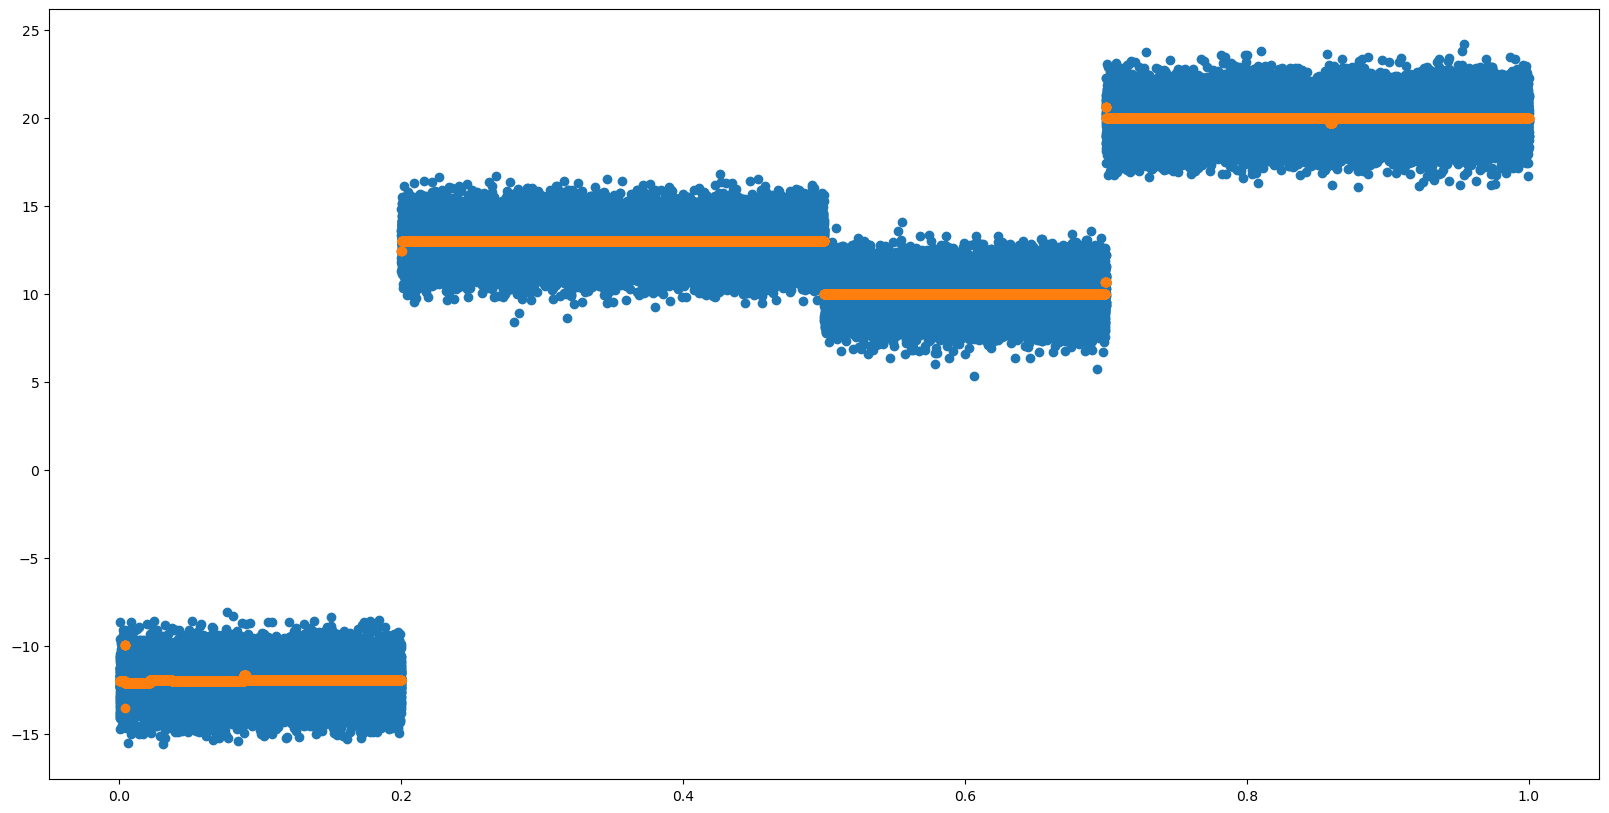

In [5]:
y_pred = rt.predict(X_test)
plt.scatter(X,y)
plt.scatter(X_test,y_pred)

In [6]:
n_nodes = rt.tree_.node_count
children_left = rt.tree_.children_left
children_right = rt.tree_.children_right
feature = rt.tree_.feature
threshold = rt.tree_.threshold

node_depth = np.zeros(shape=n_nodes, dtype=np.int64)
is_leaves = np.zeros(shape=n_nodes, dtype=bool)
stack = [(0, 0)]  # start with the root node id (0) and its depth (0)
while len(stack) > 0:
    # `pop` ensures each node is only visited once
    node_id, depth = stack.pop()
    node_depth[node_id] = depth

    # If the left and right child of a node is not the same we have a split
    # node
    is_split_node = children_left[node_id] != children_right[node_id]
    # If a split node, append left and right children and depth to `stack`
    # so we can loop through them
    if is_split_node:
        stack.append((children_left[node_id], depth + 1))
        stack.append((children_right[node_id], depth + 1))
    else:
        is_leaves[node_id] = True

print("The binary tree structure has {n} nodes and has "
      "the following tree structure:\n".format(n=n_nodes))
for i in range(n_nodes):
    if is_leaves[i]:
        print("{space}node={node} is a leaf node.".format(
            space=node_depth[i] * "\t", node=i))
    else:
        print("{space}node={node} is a split node: "
              "go to node {left} if X[:, {feature}] <= {threshold} "
              "else to node {right}.".format(
                  space=node_depth[i] * "\t",
                  node=i,
                  left=children_left[i],
                  feature=feature[i],
                  threshold=threshold[i],
                  right=children_right[i]))

The binary tree structure has 31 nodes and has the following tree structure:

node=0 is a split node: go to node 1 if X[:, 0] <= 0.2000105082988739 else to node 16.
	node=1 is a split node: go to node 2 if X[:, 0] <= 0.021395502611994743 else to node 9.
		node=2 is a split node: go to node 3 if X[:, 0] <= 0.0038265128387138247 else to node 6.
			node=3 is a split node: go to node 4 if X[:, 0] <= 0.0037434569094330072 else to node 5.
				node=4 is a leaf node.
				node=5 is a leaf node.
			node=6 is a split node: go to node 7 if X[:, 0] <= 0.0038767846999689937 else to node 8.
				node=7 is a leaf node.
				node=8 is a leaf node.
		node=9 is a split node: go to node 10 if X[:, 0] <= 0.08846544474363327 else to node 13.
			node=10 is a split node: go to node 11 if X[:, 0] <= 0.03729824349284172 else to node 12.
				node=11 is a leaf node.
				node=12 is a leaf node.
			node=13 is a split node: go to node 14 if X[:, 0] <= 0.08948185667395592 else to node 15.
				node=14 is a leaf node.
		

In [14]:
ind_sort = np.argsort(X_train[:,0])
X_train = X_train[ind_sort,:]
y_train = y_train[ind_sort]

In [7]:
# Gets relevant data from the given data, nodes etc
def splitter_fn(split_point, X, Y):
    n = X.shape[0]
    n_a = np.sum( X <= split_point)
    n_b = n - n_a

    # Calculate MSEP Ratio
    A0 = (n+1)/(n-1) * (np.eye(n) - 1/n * np.ones((n,n)))
    MSEP0 = Y.dot(A0.dot(Y))

    QA = np.zeros((n,n))
    QA[:n_a,:n_a] = np.eye(n_a) - 1/n_a * np.ones((n_a,n_a)) #First n_a x n_a block
    
    QB = np.zeros((n,n))
    QB[-n_b:,-n_b:] = np.eye(n_b) - 1/n_b * np.ones((n_b,n_b))# Last n_b x n_b block
    A1 = (n_a+1)/(n_a-1) * QA + (n_b+1)/(n_b-1) * QB
    MSEP1 = Y.dot(A1.dot(Y))
    r = MSEP1/MSEP0

    # Evaluate MSEP Ratio
    return r, n_a, n_b

#splitter_fn(threshold[0], X_train,y_train)

In [17]:
path = rt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

clfs = []
for ccp_alpha in ccp_alphas:
    clf = tree.DecisionTreeRegressor(random_state=0, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

In [18]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]

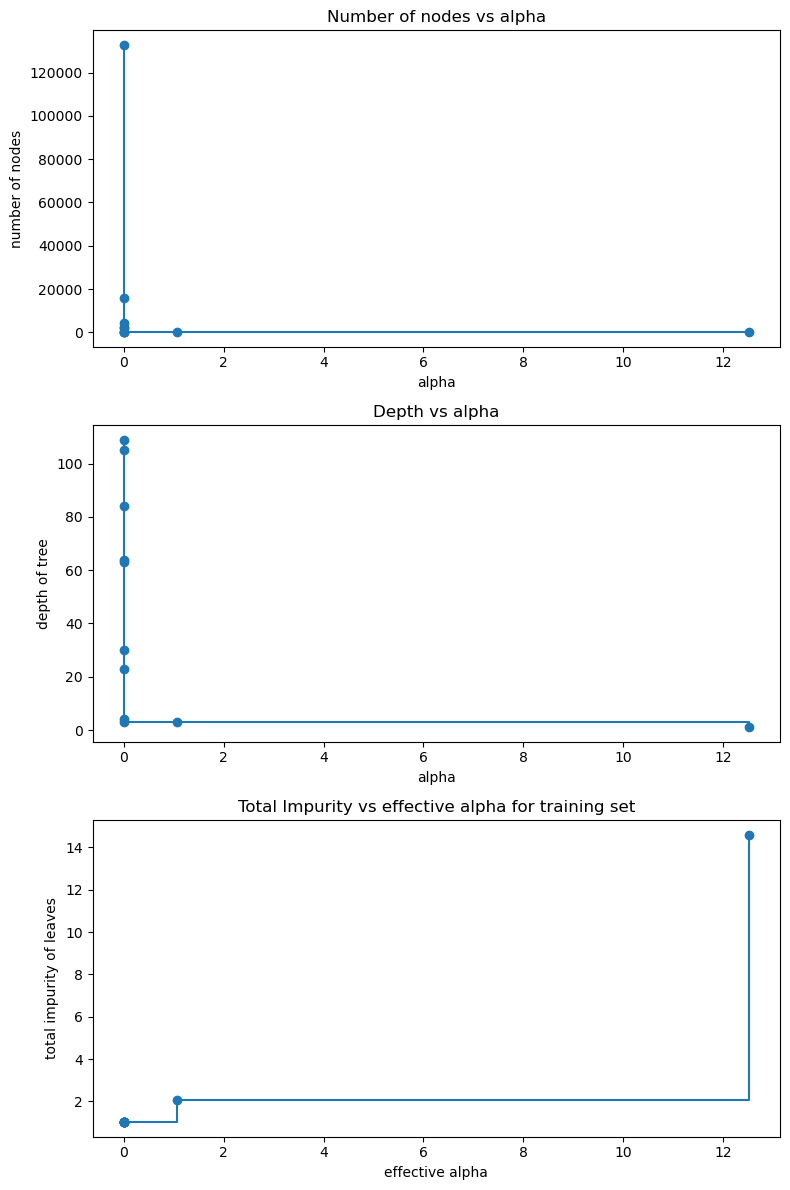

In [29]:
node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(3, 1, figsize=(8, 12))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
ax[2].plot(ccp_alphas, impurities[:-1], marker="o", drawstyle="steps-post")
ax[2].set_xlabel("effective alpha")
ax[2].set_ylabel("total impurity of leaves")
ax[2].set_title("Total Impurity vs effective alpha for training set")
fig.tight_layout()

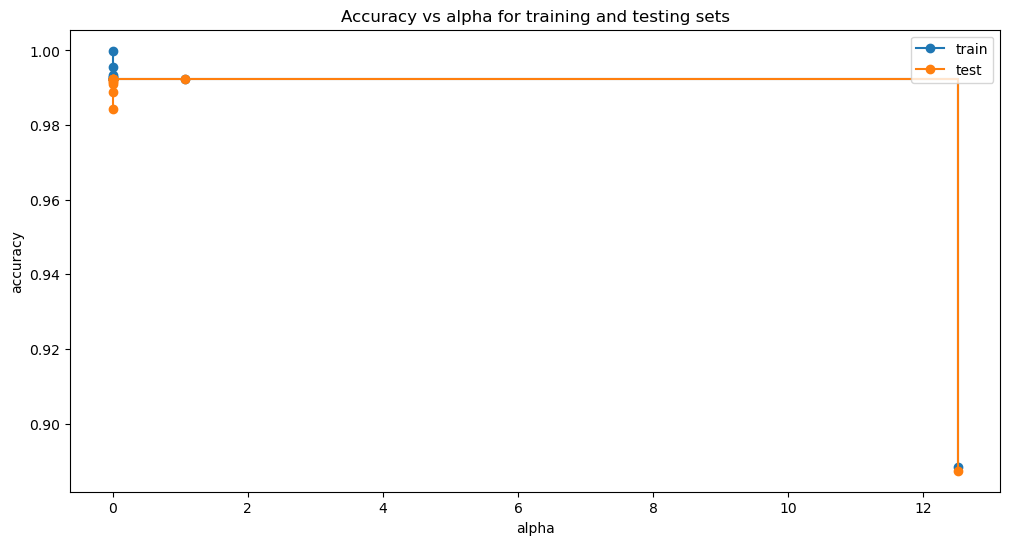

In [33]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

fig, ax = plt.subplots(figsize=(12,6))
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()